In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence
from sim_library.plotting import plot_state_trajectories, plot_bloch, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt


### NOT Gate

In [5]:
p_min = -1
p_max = 5
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 100

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 0
initial_state[1] = 1
initial_state[2] = 1
initial_state[3] = 1
initial_state[4] = 0
initial_state[5] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

not_gate = PulseSequence()

freevolve_halfpi = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time/2) #pi/2
pi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)

not_gate.add_pulses([freevolve_halfpi, pi_pulse, freevolve_halfpi])

wave_func, times = simulate_pulses_single_atom(pulse_seq= not_gate, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

print(np.round(np.square(np.abs(wave_func[-1,:])), 5))

display_table_compare(basis=basis, init_state=initial_state, final_state=wave_func[-1,:])



[0. +0.j 0.5+0.j 0.5+0.j 0.5+0.j 0. +0.j 0.5+0.j 0. +0.j]
[0.00000000e+00+0.00000000e+00j 5.00000000e-01+7.93616718e-06j
 5.00000000e-01+7.93616718e-06j 7.42840435e-05-3.06657575e-03j
 4.99778662e-01+1.45560805e-02j 5.34518600e-04-6.11148767e-03j
 4.97611211e-01+4.84298094e-02j]
[0.0000e+00 2.5000e-01 2.5000e-01 1.0000e-05 2.4999e-01 4.0000e-05
 2.4996e-01]
+---------+---------------------+---------------+---------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |   Initial Psi |           Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+===============+=====================+===================+=================+
|       0 |                  -1 |       0j|111> |             0j|111> |              0    |            0    |
+---------+---------------------+---------------+---------------------+-------------------+-----------------+
|       1 |                   0 | (0.5+0j)|000> |       (0.5+0j)|000> |              0.25 

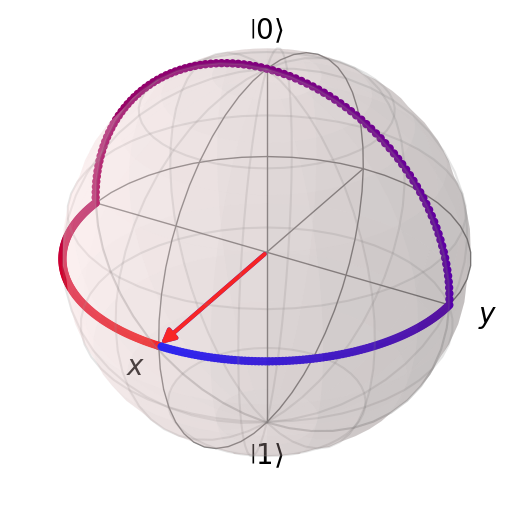

In [6]:
eee = wave_func[:,1:3]
eee = eee/ np.linalg.norm(eee[0])
plot_bloch(wave_func=eee)

In [7]:
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 100

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 2
initial_state[1] = 1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

not_gate = PulseSequence()

freevolve_halfpi = FreeEvolution(laser_det=(np.full(time_steps, omega_eg/2)), duration=omega_time/2) #pi/2
pi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2)

not_gate.add_pulses([pi_pulse])

wave_func, times = simulate_pulses_single_atom(pulse_seq= not_gate, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

print(len(wave_func))

[0.89442719+0.j 0.4472136 +0.j]
[ 3.42434414e-15-0.4472136j  -1.71043735e-15-0.89442719j]
101


### CP1

In [11]:
# Inverts phase if state = 0

p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 50

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 2
initial_state[1] = 1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

cpone = PulseSequence()

freevolve_pi = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) #pi
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

cpone.add_pulses([twopi_pulse, freevolve_pi])

wave_func, times = simulate_pulses_single_atom(pulse_seq= cpone, basis= basis, initial_state=initial_state, d_shift=0)

print(wave_func[-1,:])

[0.89442719+0.j 0.4472136 +0.j]
[-0.89442719-2.11636264e-16j  0.4472136 +1.41966474e-05j]


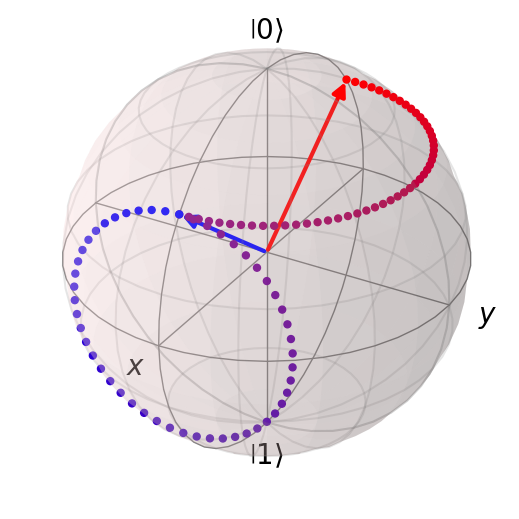

In [12]:
plot_bloch(wave_func=wave_func)

### Hadamard

In [23]:
p_min = 0
p_max = 1
basis = np.arange(p_min, p_max + 1)

rabi_freq = 2*pi*10000000
rabi_time = 2*pi/rabi_freq

time_steps = 50

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[0] = 1
initial_state[1] = -1
# initial_state[2] = 1
# initial_state[3] = -1

initial_state = initial_state/ np.linalg.norm(initial_state)

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

print(initial_state)

hadamard = PulseSequence()

freevolve_pi = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) #pi
halfpi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
twopi_pulse = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time)

hadamard.add_pulses([twopi_pulse, freevolve_pi, halfpi_pulse])

wave_func, times = simulate_pulses_single_atom(pulse_seq= hadamard, basis= basis, initial_state=initial_state, d_shift=0)

beep = initial_state.reshape(2,1)
hadamardmat = (1/np.sqrt(2))*np.array([[1,1],[1,-1]])
simmed = np.dot(hadamardmat, beep) 

print("sim:",wave_func[-1,:])
print("target:",simmed.transpose()[0])



[ 0.70710678+0.j -0.70710678+0.j]
sim: [-2.51934473e-10+1.58723344e-05j -1.00000000e+00-1.58723344e-05j]
target: [0.+0.j 1.+0.j]


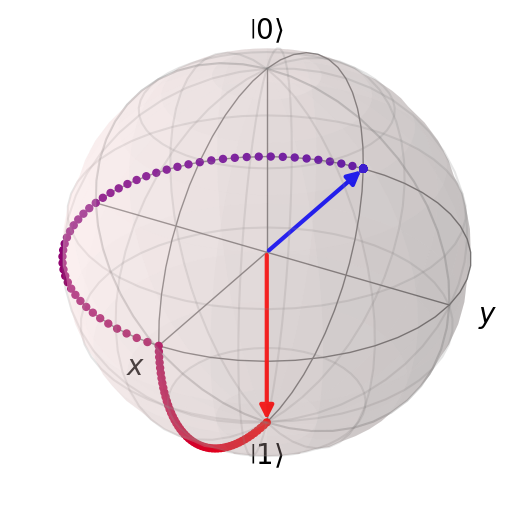

In [24]:
plot_bloch(wave_func=wave_func)

In [40]:
print(omega_eg)
print(dR)

19074060415.5
96368.27489031358


In [92]:
print(np.exp(1j*pi/2))

(6.123233995736766e-17+1j)
